In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('calories.csv')
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
df.shape

(15000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [6]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [7]:
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Duplicate Rows ===')
print('Duplicates:', df.duplicated().sum())
print()
print('=== Data Types ===')
print(df.dtypes)

=== Missing Values ===
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

=== Duplicate Rows ===
Duplicates: 0

=== Data Types ===
User_ID         int64
Gender         object
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object


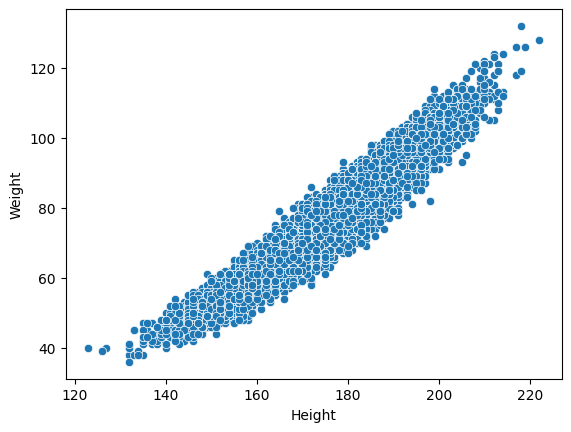

In [8]:
sb.scatterplot(x='Height', y='Weight', data=df)
plt.show()

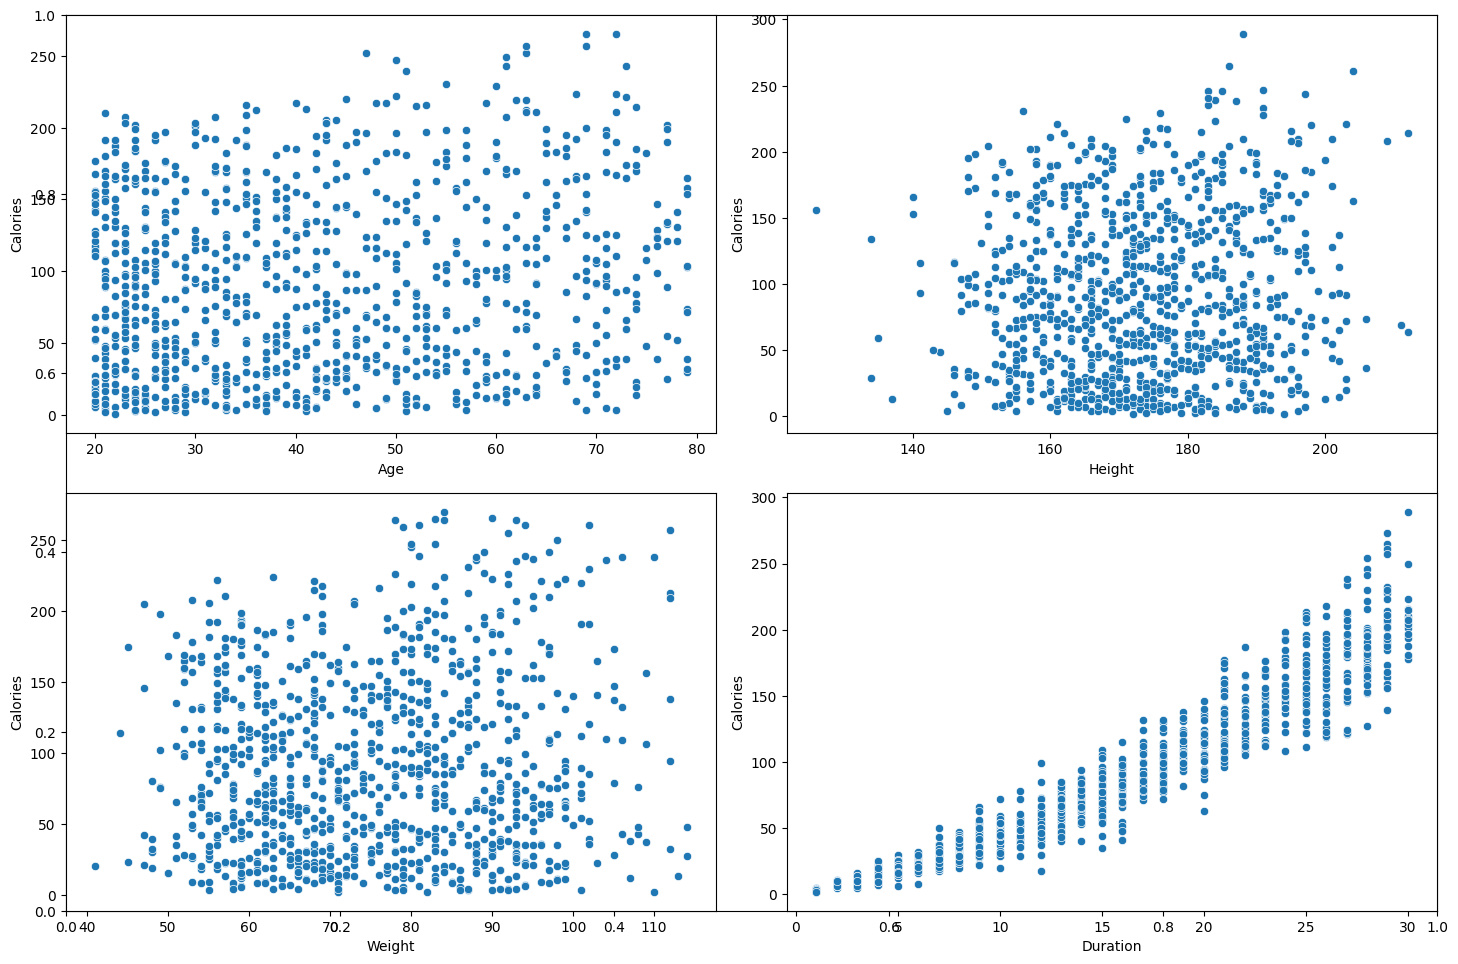

In [9]:
features = ['Age', 'Height', 'Weight', 'Duration']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    x = df.sample(1000)
    sb.scatterplot(x=col, y='Calories', data=x)
plt.tight_layout()
plt.show()

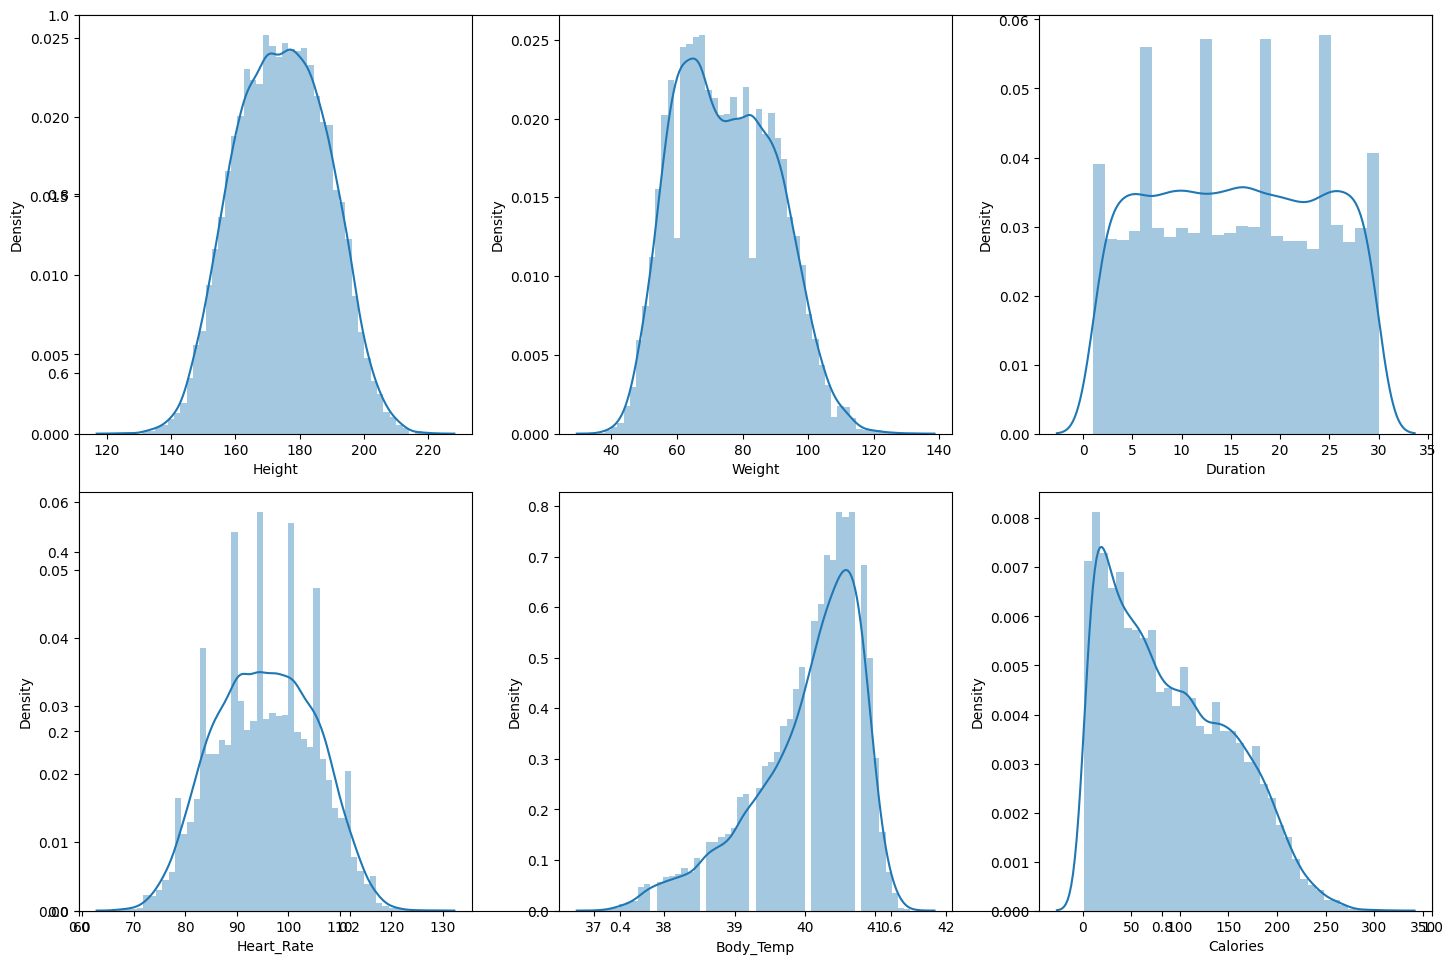

In [10]:
features = df.select_dtypes(include='float').columns

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sb.distplot(df[col])
plt.tight_layout()
plt.show()

In [11]:
df.replace({'male': 0, 'female': 1},inplace=True)
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


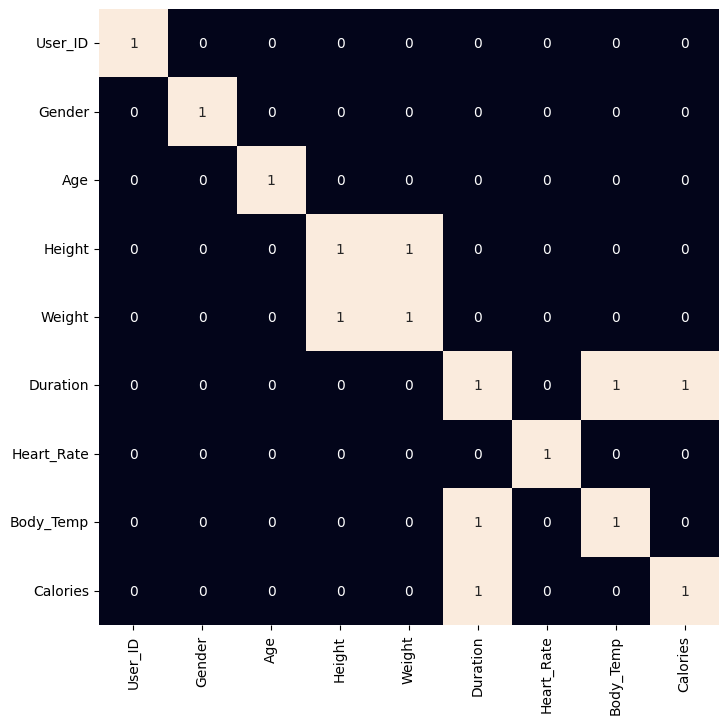

In [12]:
plt.figure(figsize=(8, 8))
sb.heatmap(df.corr() > 0.9,annot=True,cbar=False)
plt.show()

In [13]:
to_remove = ['Weight', 'Duration']
df.drop(to_remove, axis=1, inplace=True)

In [19]:
features = df.drop(['User_ID', 'Calories'], axis=1)
target = df['Calories'].values
X_train, X_val,\
Y_train, Y_val = train_test_split(features, target,test_size=0.1,random_state=22)
X_train.shape, X_val.shape

((13500, 5), (1500, 5))

In [20]:
# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [21]:
from sklearn.metrics import mean_absolute_error as mae
models = [LinearRegression(), XGBRegressor(),
          Lasso(), RandomForestRegressor(), Ridge()]

for i in range(5):
    models[i].fit(X_train, Y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    val_preds = models[i].predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print()

LinearRegression() : 
Training Error :  17.893463692619434
Validation Error :  18.007896272831253

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Error :  7.89463304294701
Validation Error :  10.12050432946533

Lasso() : 
Training Error :  17.915089584958036
Validation Error :  17.995

In [22]:
# Evaluation Metrics
# For regression tasks, we report MAE, MSE, RMSE, and R² (which map to
# accuracy-like, recall-like quality of fit measures).
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_names  = ['Linear Regression', 'XGBoost', 'Lasso', 'Random Forest', 'Ridge']
results = []

for name, model in zip(model_names, models):
    val_preds   = model.predict(X_val)
    train_preds = model.predict(X_train)
    mae_val  = mean_absolute_error(Y_val, val_preds)
    mse_val  = mean_squared_error(Y_val, val_preds)
    rmse_val = np.sqrt(mse_val)
    r2_val   = r2_score(Y_val, val_preds)
    results.append({'Model': name, 'MAE': round(mae_val,3),
                    'MSE': round(mse_val,3), 'RMSE': round(rmse_val,3),
                    'R2 Score': round(r2_val,4)})

import pandas as pd
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                      MAE      MSE    RMSE  R2 Score
Model                                               
Linear Regression  18.008  520.824  22.822    0.8630
XGBoost            10.121  204.197  14.290    0.9463
Lasso              17.995  521.679  22.840    0.8628
Random Forest      10.506  221.053  14.868    0.9419
Ridge              18.008  520.815  22.821    0.8630


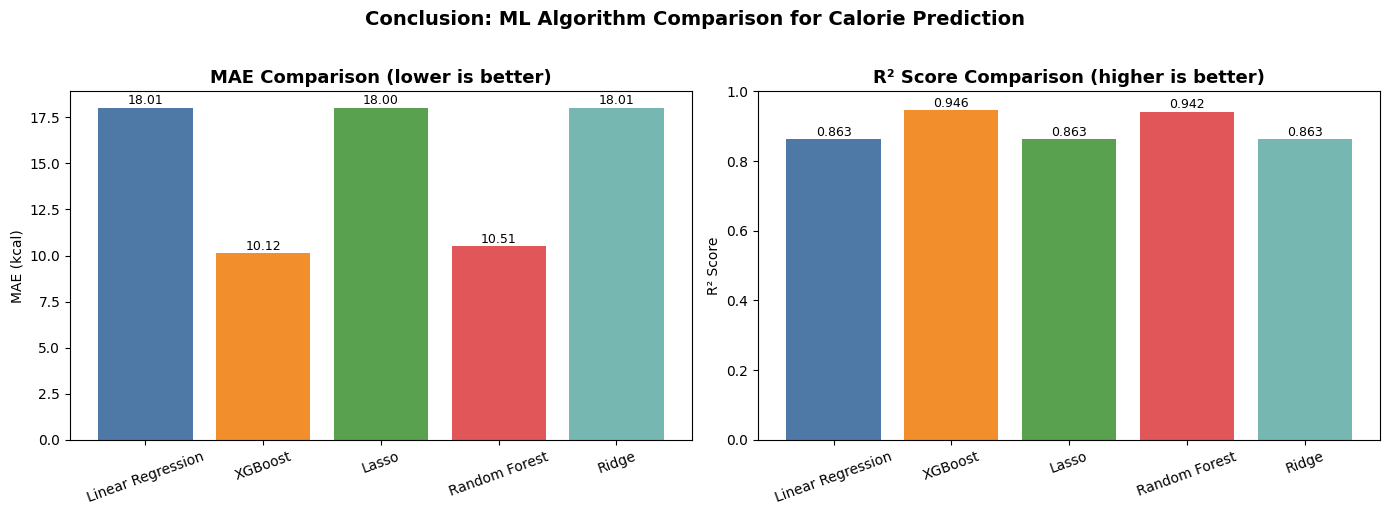


 Best Algorithm: XGBoost with MAE = 10.121 kcal
 Highest R²:     XGBoost (0.9463)


In [23]:
#Algorithm Comparison
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison (lower is better)
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759','#76b7b2']
axes[0].bar(results_df.index, results_df['MAE'], color=colors)
axes[0].set_title('MAE Comparison (lower is better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MAE (kcal)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['MAE']):
    axes[0].text(i, v + 0.2, f'{v:.2f}', ha='center', fontsize=9)

# R² comparison (higher is better)
axes[1].bar(results_df.index, results_df['R2 Score'], color=colors)
axes[1].set_title('R² Score Comparison (higher is better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['R2 Score']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Conclusion: ML Algorithm Comparison for Calorie Prediction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best = results_df['MAE'].idxmin()
print(f'\n Best Algorithm: {best} with MAE = {results_df.loc[best, "MAE"]} kcal')
print(f' Highest R²:     {results_df["R2 Score"].idxmax()} '
      f'({results_df["R2 Score"].max()})')
